In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# nltk.download("stopwords")
# nltk.download("punkt")

In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import string

stemmer = PorterStemmer()

stop_words = stopwords.words('english')

def transform_text(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    tokens = [word for word in tokens if (word not in stop_words) and (word not in string.punctuation)]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

In [ ]:
# !pip install wordcloud

# spam.csv

Link: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [61]:
spam_df = pd.read_csv('/content/drive/MyDrive/DPL/Project/Data/spam.csv', encoding='ISO-8859-1')

In [28]:
spam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [62]:
# Xóa 3 cột Unnamed: 2, Unnamed: 3, Unnamed: 4
spam_df = spam_df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Đổi tên cột v1 thành label, v2 thành message
spam_df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)

# ham = 0, spam = 1
spam_df['label'] = spam_df['label'].map({'ham': 0, 'spam': 1})

In [30]:
spam_df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
print(spam_df.duplicated().sum())
print(spam_df.isna().sum())

403
label      0
message    0
dtype: int64


In [63]:
spam_df.drop_duplicates(inplace=True)

In [33]:
spam_df.shape

(5169, 2)

In [124]:
spam_df['num_words'] = spam_df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
spam_df['num_sentences'] = spam_df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))
spam_df[['num_words','num_sentences']].describe()

,num_words,num_sentences
count,5169.000000,5169.000000
mean,18.455794,1.965564
std,13.324758,1.448541
min,1.000000,1.000000
25%,9.000000,1.000000
50%,15.000000,1.000000
75%,26.000000,2.000000
max,220.000000,38.000000


In [64]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [65]:
spam_df['tranform_message'] = spam_df['message'].apply(transform_text)

(-0.5, 499.5, 499.5, -0.5)

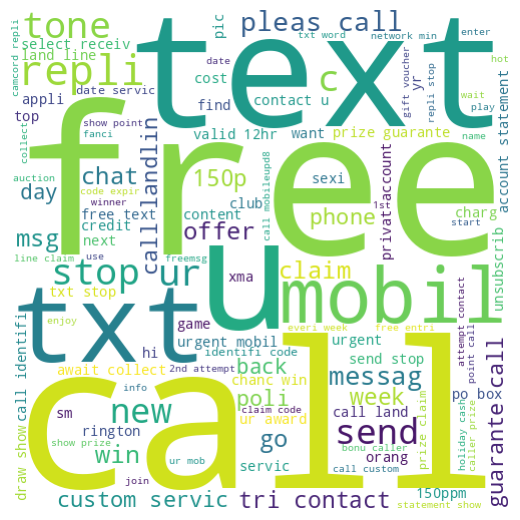

In [92]:
spam_wc = wc.generate(spam_df[spam_df['label']==1]['tranform_message'].str.cat(sep=' '))
plt.figure(figsize=(6.5, 6.5))
plt.imshow(spam_wc)
plt.axis('off')

(-0.5, 499.5, 499.5, -0.5)

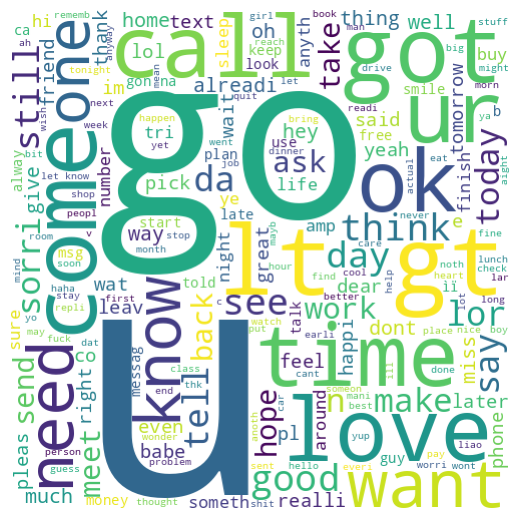

In [82]:
ham_wc = wc.generate(spam_df[spam_df['label']==0]['tranform_message'].str.cat(sep=' '))
plt.figure(figsize=(6.5, 6.5))
plt.imshow(ham_wc)
plt.axis('off')

Text(0.5, 1.0, 'Top 30 Most Common Words in Spam Corpus')

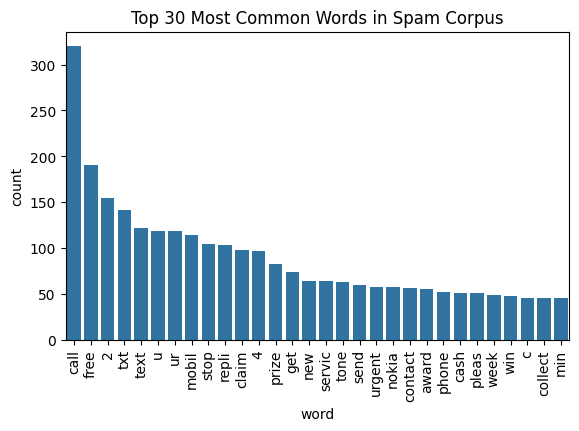

In [116]:
from collections import Counter

spam_corpus = []
for msg in spam_df[spam_df['label']==1]['tranform_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

common_spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
plt.figure(figsize=(6.5, 4))
sns.barplot(x='word', y='count', data=common_spam_words_df)  # Chọn cột từ DataFrame
plt.xticks(rotation='vertical')  # Xoay nhãn trục x theo chiều dọc
plt.title("Top 30 Most Common Words in Spam Corpus")  # Thêm tiêu đề

Text(0.5, 1.0, 'Top 30 Most Common Words in Ham Corpus')

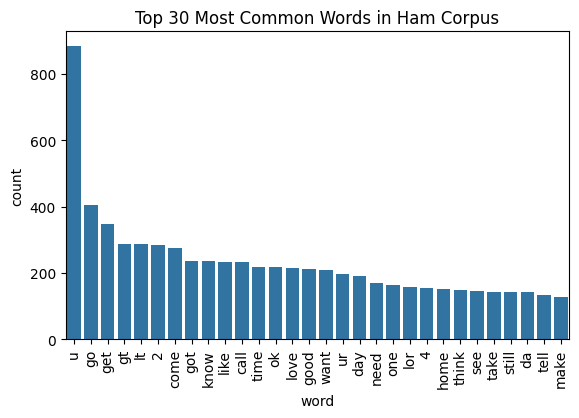

In [117]:
ham_corpus = []
for msg in spam_df[spam_df['label']==0]['tranform_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

common_ham_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
plt.figure(figsize=(6.5, 4))
sns.barplot(x='word', y='count', data=common_ham_words_df)  # Chọn cột từ DataFrame
plt.xticks(rotation='vertical')  # Xoay nhãn trục x theo chiều dọc
plt.title("Top 30 Most Common Words in Ham Corpus")  # Thêm tiêu đề

,count
label,
0,4516
1,653


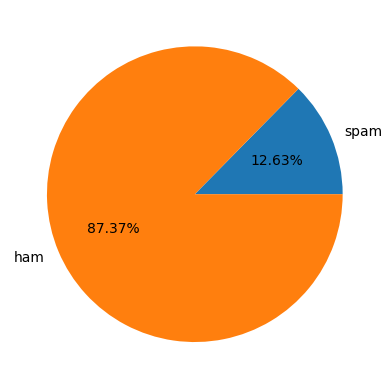

In [13]:
size = (spam_df['label'].value_counts().sort_values() / spam_df.shape[0] * 100).tolist()
plt.pie(size, labels=['spam', 'ham'], autopct='%1.2f%%')
spam_df['label'].value_counts()

# spamraw.csv

Link: https://www.kaggle.com/datasets/shravan3273/sms-spam

In [14]:
spamraw_df = pd.read_csv('/content/drive/MyDrive/DPL/Project/Data/spamraw.csv')

In [15]:
spamraw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5559 entries, 0 to 5558
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    5559 non-null   object
 1   text    5559 non-null   object
dtypes: object(2)
memory usage: 87.0+ KB


In [16]:
# Đổi tên cột type thành label, text thành message
spamraw_df.rename(columns={'type': 'label', 'text': 'message'}, inplace=True)

# ham = 0, spam = 1
spamraw_df['label'] = spamraw_df['label'].map({'ham': 0, 'spam': 1})

In [17]:
spamraw_df.head()

,label,message
0,0,Hope you are having a good week. Just checking in
1,0,K..give back my thanks.
2,0,Am also doing in cbe only. But have to pay.
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,1,okmail: Dear Dave this is your final notice to...


In [18]:
print(spamraw_df.duplicated().sum())
print(spamraw_df.isna().sum())

403
label      0
message    0
dtype: int64


In [19]:
spamraw_df.drop_duplicates(inplace=True)

In [125]:
spamraw_df['num_words'] = spamraw_df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
spamraw_df['num_sentences'] = spamraw_df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))
spamraw_df[['num_words','num_sentences']].describe()

,num_words,num_sentences
count,5156.000000,5156.000000
mean,18.174166,1.974011
std,12.756129,1.458812
min,1.000000,1.000000
25%,9.000000,1.000000
50%,14.000000,1.500000
75%,26.000000,2.000000
max,196.000000,38.000000


In [120]:
spamraw_df['tranform_message'] = spamraw_df['message'].apply(transform_text)

(-0.5, 499.5, 499.5, -0.5)

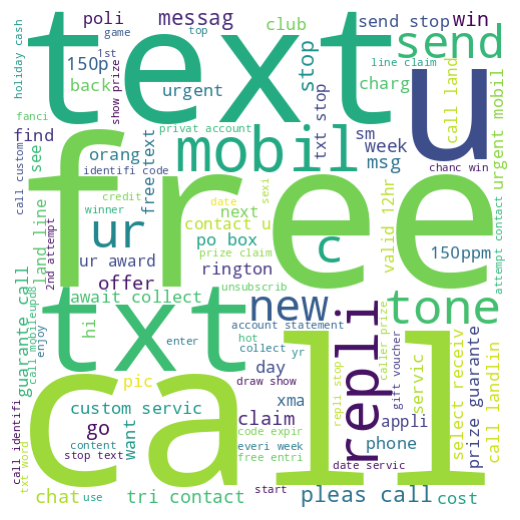

In [93]:
spam_wc = wc.generate(spamraw_df[spamraw_df['label']==1]['tranform_message'].str.cat(sep=' '))
plt.figure(figsize=(6.5, 6.5))
plt.imshow(spam_wc)
plt.axis('off')

(-0.5, 499.5, 499.5, -0.5)

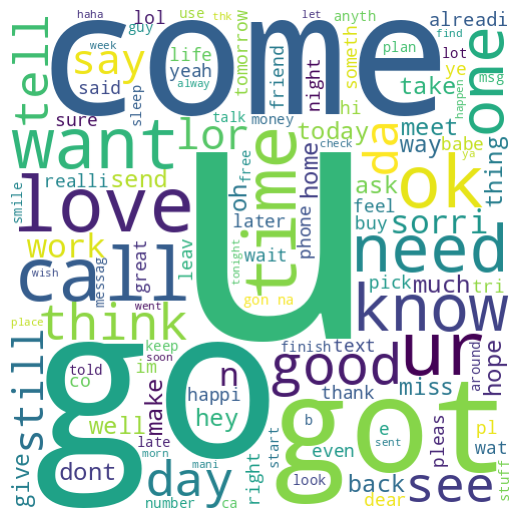

In [94]:
ham_wc = wc.generate(spamraw_df[spamraw_df['label']==0]['tranform_message'].str.cat(sep=' '))
plt.figure(figsize=(6.5, 6.5))
plt.imshow(ham_wc)
plt.axis('off')

Text(0.5, 1.0, 'Top 30 Most Common Words in Spam Corpus')

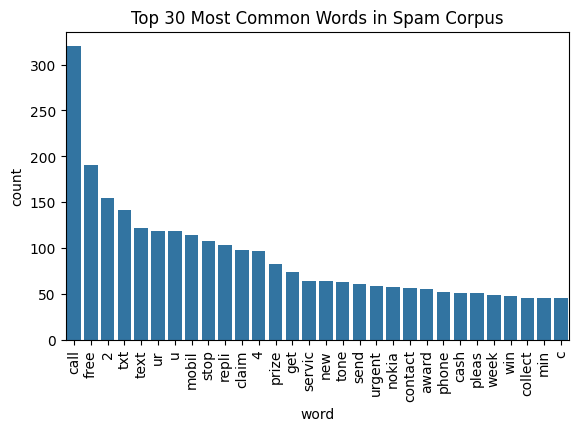

In [121]:
spam_corpus = []
for msg in spamraw_df[spamraw_df['label']==1]['tranform_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

common_spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
plt.figure(figsize=(6.5, 4))
sns.barplot(x='word', y='count', data=common_spam_words_df)  # Chọn cột từ DataFrame
plt.xticks(rotation='vertical')  # Xoay nhãn trục x theo chiều dọc
plt.title("Top 30 Most Common Words in Spam Corpus")  # Thêm tiêu đề

Text(0.5, 1.0, 'Top 30 Most Common Words in Ham Corpus')

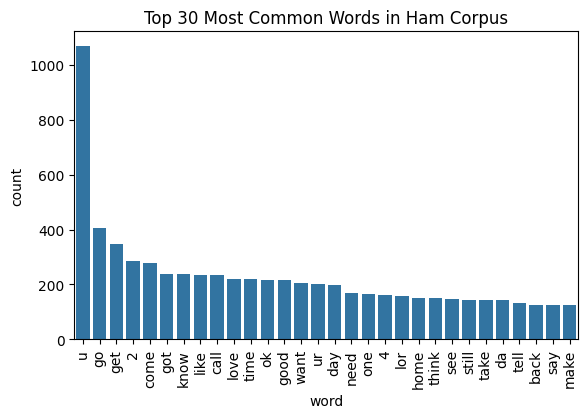

In [122]:
ham_corpus = []
for msg in spamraw_df[spamraw_df['label']==0]['tranform_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

common_ham_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
plt.figure(figsize=(6.5, 4))
sns.barplot(x='word', y='count', data=common_ham_words_df)  # Chọn cột từ DataFrame
plt.xticks(rotation='vertical')  # Xoay nhãn trục x theo chiều dọc
plt.title("Top 30 Most Common Words in Ham Corpus")  # Thêm tiêu đề

,count
label,
0,4503
1,653


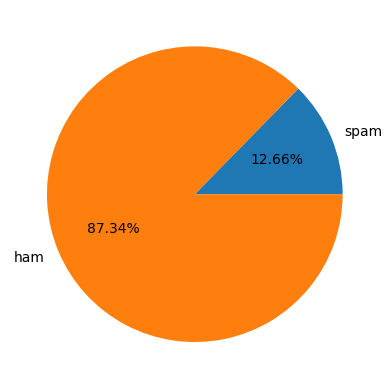

In [ ]:
size = (spamraw_df['label'].value_counts().sort_values() / spamraw_df.shape[0] * 100).tolist()
plt.pie(size, labels=['spam', 'ham'], autopct='%1.2f%%')
spamraw_df['label'].value_counts()

# Gộp spam.csv với spamraw.csv

In [ ]:
df_concatenated = pd.concat([spam_df, spamraw_df], axis=0)

In [ ]:
df_concatenated.shape

(10325, 2)

,count
label,
0,9019
1,1306


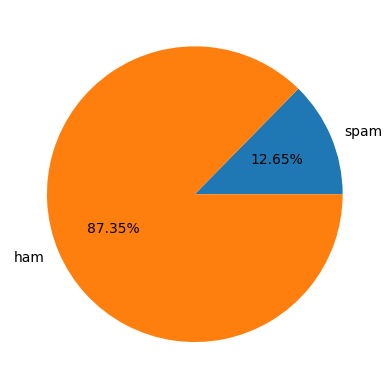

In [ ]:
size = (df_concatenated['label'].value_counts().sort_values() / df_concatenated.shape[0] * 100).tolist()
plt.pie(size, labels=['spam', 'ham'], autopct='%1.2f%%')
df_concatenated['label'].value_counts()

# Xử lý Imbalance data bằng phương pháp oversampling

In [ ]:
label_1 = df_concatenated[df_concatenated['label'] == 1]
label_0 = df_concatenated[df_concatenated['label'] == 0]

In [ ]:
label_1_over = label_1.sample(label_0.shape[0], replace=True)
df_concatenated_over = pd.concat([label_1_over, label_0], axis=0)

In [ ]:
print(df_concatenated_over.shape)
df_concatenated_over['label'].value_counts()

(18038, 2)


,count
label,
1,9019
0,9019


In [ ]:
df_concatenated_over_shuffled = df_concatenated_over.sample(df_concatenated_over.shape[0]).reset_index(drop=True)

In [ ]:
df_concatenated_over_shuffled.shape

(18038, 2)

In [ ]:
df_concatenated_over_shuffled.to_csv('/content/drive/MyDrive/DPL/Project/balanced_spam.csv', index=False)